# SHAP Explainability for Telco Churn Model

**Objective:** Understand *why* the model predicts churn for individual customers and identify the most important features globally.

**Dataset:** Preprocessed Telco Customer Churn data, same train/test split as `modeling.ipynb`.

**Overview:**
1. Load saved model artifacts (preprocessor + XGBoost)
2. Compute SHAP values on test data
3. Global feature importance via summary and bar plots
4. Feature interaction effects via dependence plots
5. Individual prediction breakdown via waterfall and force plots
6. Compare churners vs. non-churners to find separating features

---

### Table of Contents
1. [Setup & Imports](#1)
2. [Load Artifacts](#2)
3. [Prepare Test Data](#3)
4. [SHAP Explainer](#4)
5. [Global Feature Importance](#5)
6. [Dependence Plots](#6)
7. [Individual Prediction Breakdown](#7)
8. [Compare Churners vs. Non-Churners](#8)
9. [Key Takeaways](#9)

---
## 1. Setup & Imports <a id='1'></a>

In [10]:
import warnings

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

import sys
sys.path.insert(0, '../src')

from customer_churn_ml.data.ingestion import load_raw_data
from customer_churn_ml.data.preprocess import encode_binary_columns
from customer_churn_ml.features.build_features import build_features
from customer_churn_ml.utils.config import load_config

shap.initjs()
warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

---
## 2. Load Artifacts <a id='2'></a>

Load the **preprocessor** (fitted `ColumnTransformer`) and the **trained XGBoost model** saved by `scripts/train.py`.

In [11]:
MODEL_DIR = '../src/customer_churn_ml/serving/model/'

preprocessor = joblib.load(MODEL_DIR + 'preprocessor.joblib')

model = XGBClassifier()
model._estimator_type = 'classifier'
model.load_model(MODEL_DIR + 'model.ubj')

with open(MODEL_DIR + 'feature_names.json') as f:
    feature_names = json.load(f)

print(f'Model type: {type(model).__name__}')
print(f'Feature count: {len(feature_names)}')
print(f'First 10 features: {feature_names[:10]}')

Model type: XGBClassifier
Feature count: 37
First 10 features: ['tenure', 'monthly_charges', 'total_charges', 'senior_citizen', 'num_services', 'avg_monthly_charge', 'multiple_lines_No phone service', 'multiple_lines_Yes', 'internet_service_Fiber optic', 'internet_service_No']


---
## 3. Prepare Test Data <a id='3'></a>

Load raw data, apply feature engineering, and use the **same train/test split** as the training script so SHAP values correspond to unseen data.

In [12]:
config = load_config()
df = load_raw_data(config['paths']['raw_data'])

# Feature engineering
df = build_features(df, config)

# Target encoding
y = df['churn'].map({'Yes': 1, 'No': 0})
X = df.drop(columns=['churn'])

# Same split as training
_, X_test, _, y_test = train_test_split(
    X, y,
    test_size=config['split']['test_size'],
    random_state=config['split']['random_state'],
    stratify=y
)

# Encode binary columns to match preprocessor training format
X_test = encode_binary_columns(X_test, config['features']['binary_map'])

# Transform with the saved (already-fitted) preprocessor
X_test_proc = preprocessor.transform(X_test)
print(f'Test set shape: {X_test_proc.shape}')
print(f'Test churn rate: {y_test.mean():.3f}')

2026-05-20 00:41:22 | customer_churn_ml.data.ingestion | INFO | Loading raw data from /home/vincentoei/projects/customer-churn-ml/data/raw/telco-customer-churn-raw.csv
2026-05-20 00:41:22 | customer_churn_ml.data.ingestion | INFO | Coerced 11 blank 'total_charges' values to NaN (tenure=0 customers).
2026-05-20 00:41:22 | customer_churn_ml.data.ingestion | INFO | Dropped non-predictive column 'customer_id'.
2026-05-20 00:41:22 | customer_churn_ml.data.ingestion | INFO | Loaded DataFrame shape: (7043, 20)
2026-05-20 00:41:22 | customer_churn_ml.features.build_features | INFO | Added tenure_group (bins=[0, 12, 24, 48, 72], labels=['0-12', '13-24', '25-48', '49-72']).
2026-05-20 00:41:22 | customer_churn_ml.features.build_features | INFO | Added num_services from columns ['online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies'].
2026-05-20 00:41:22 | customer_churn_ml.features.build_features | INFO | Added avg_monthly_charge (proxy used f

---
## 4. SHAP Explainer <a id='4'></a>

`TreeExplainer` is exact and highly efficient for tree-based models (XGBoost, LightGBM, Random Forest).

In [13]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_proc)

# For binary classifiers TreeExplainer returns [shap_neg, shap_pos]
# We focus on the positive class (churn = 1)
if isinstance(shap_values, list):
    shap_values = shap_values[1]

base_val = explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value
print(f'SHAP values shape: {shap_values.shape}')
print(f'Base value (expected probability): {base_val:.4f}')

SHAP values shape: (1409, 37)
Base value (expected probability): 0.0085


---
## 5. Global Feature Importance <a id='5'></a>

### 5.1 Summary Plot (Beeswarm)

Shows how each feature's value pushes the prediction toward churn (red = high value) or retention (blue = low value).

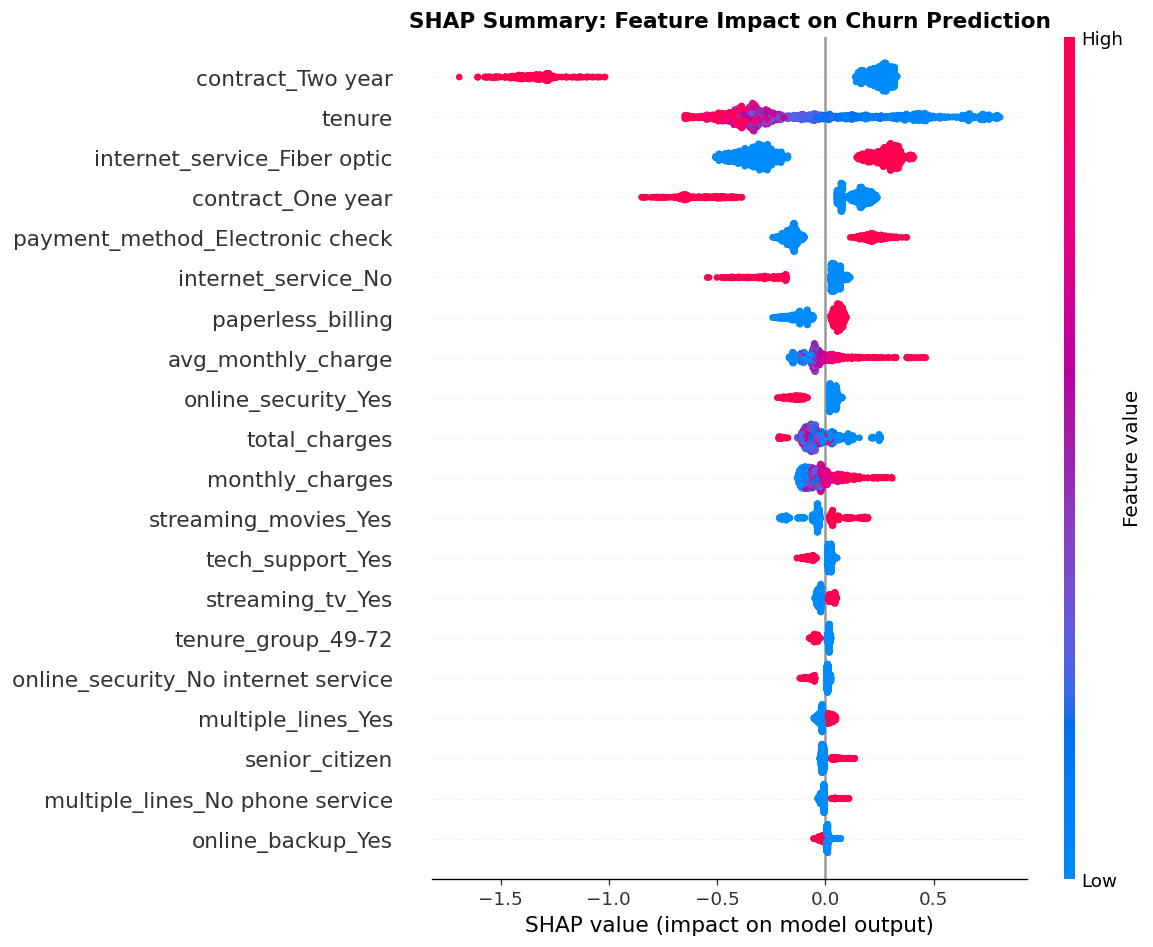

In [14]:
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test_proc,
    feature_names=feature_names,
    show=False,
    plot_size=(10, 8)
)
plt.title('SHAP Summary: Feature Impact on Churn Prediction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.2 Bar Plot (Mean Absolute SHAP)

A simpler ranking of features by average impact magnitude.

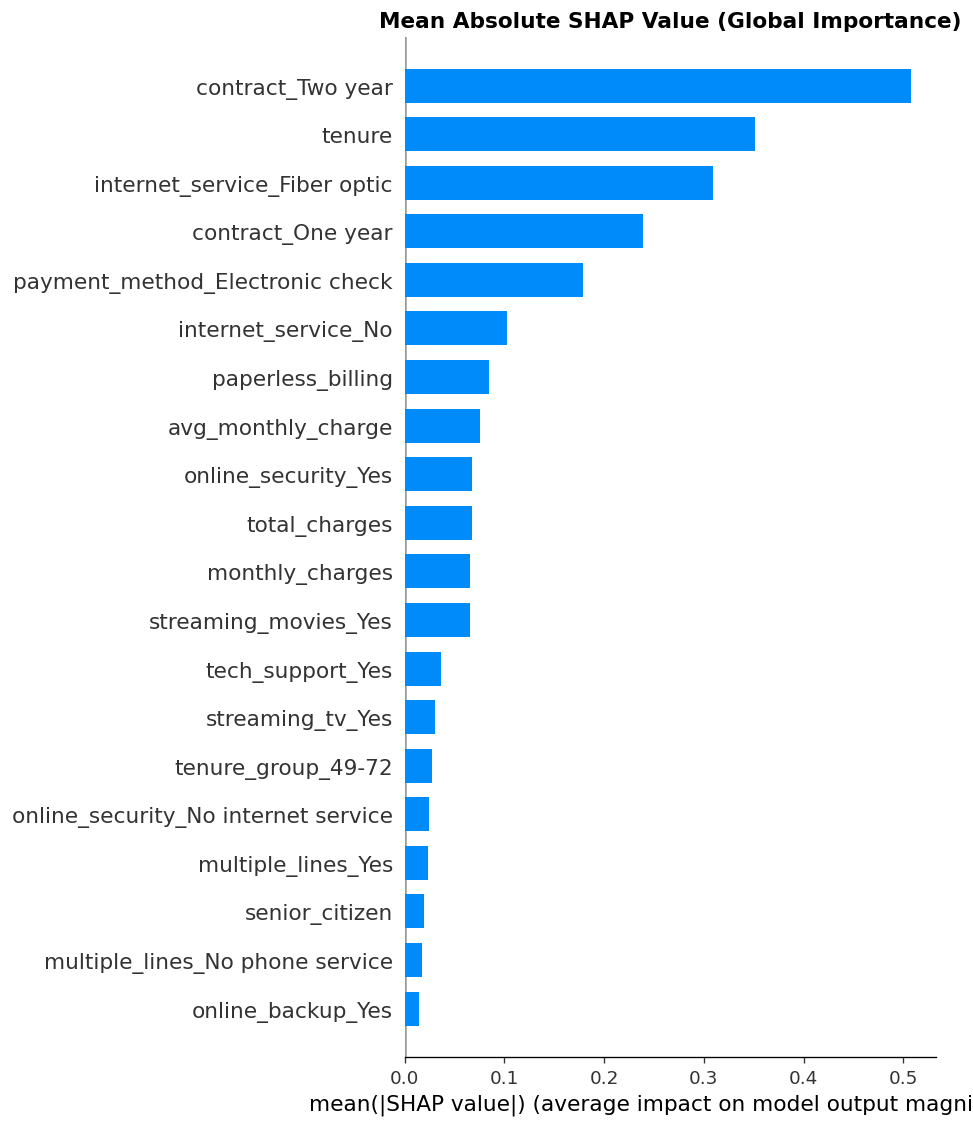

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_test_proc,
    feature_names=feature_names,
    plot_type='bar',
    show=False
)
plt.title('Mean Absolute SHAP Value (Global Importance)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Dependence Plots <a id='6'></a>

Shows how a single feature's value influences SHAP values, revealing non-linear relationships and interactions with other features.

**Try features like:** `tenure`, `monthly_charges`, `contract_Two year`, `internet_service_Fiber optic`.

Top feature selected: contract_Two year


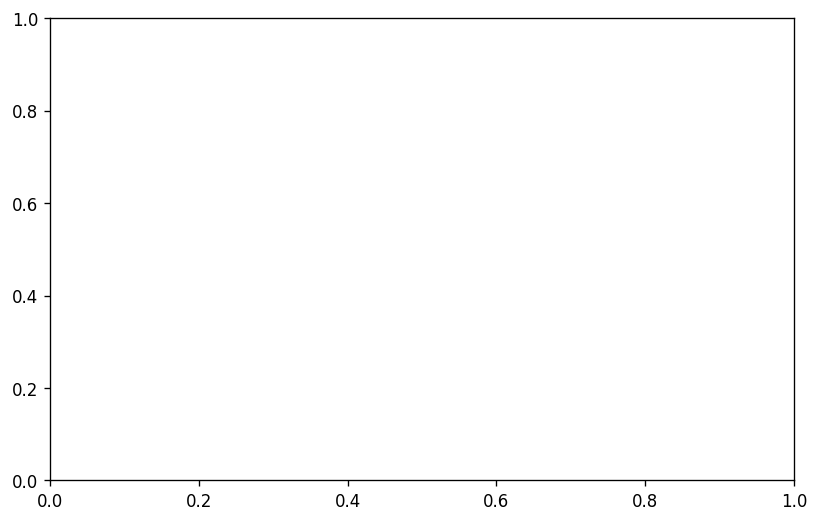

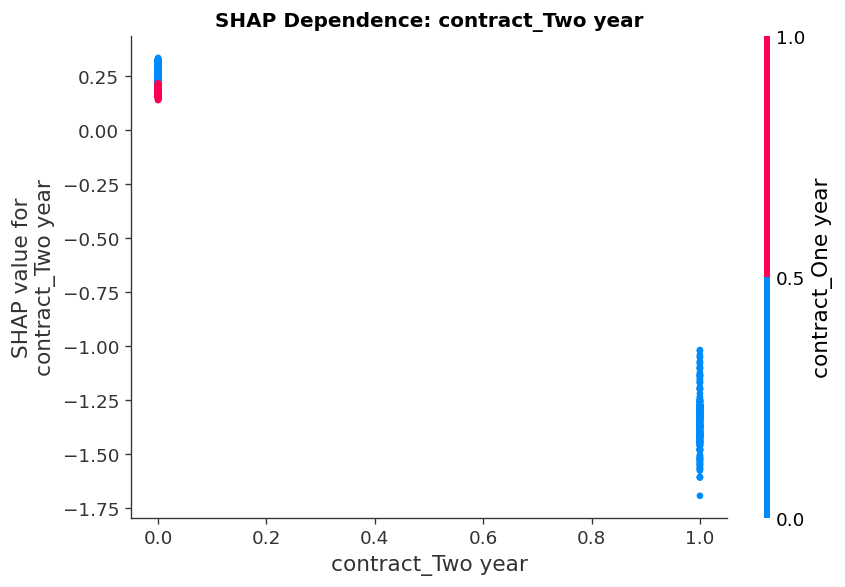

In [16]:
# Auto-detect the top feature from mean absolute SHAP
top_feature = feature_names[np.argmax(np.mean(np.abs(shap_values), axis=0))]
print(f'Top feature selected: {top_feature}')

fig, ax = plt.subplots(figsize=(8, 5))
shap.dependence_plot(
    top_feature,
    shap_values,
    X_test_proc,
    feature_names=feature_names,
    show=False,
    interaction_index='auto'
)
plt.title(f'SHAP Dependence: {top_feature}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Individual Prediction Breakdown <a id='7'></a>

Pick a churner and a non-churner to see exactly which features pushed them toward or away from churn.

In [17]:
y_test_reset = y_test.reset_index(drop=True)
churner_idx = y_test_reset[y_test_reset == 1].index[0]
non_churner_idx = y_test_reset[y_test_reset == 0].index[0]

print(f'Churner index in test set: {churner_idx}')
print(f'Non-churner index in test set: {non_churner_idx}')

Churner index in test set: 9
Non-churner index in test set: 0


### 7.1 Waterfall - Predicted Churner

Each bar shows how a feature pushes the prediction away from the base value toward churn.

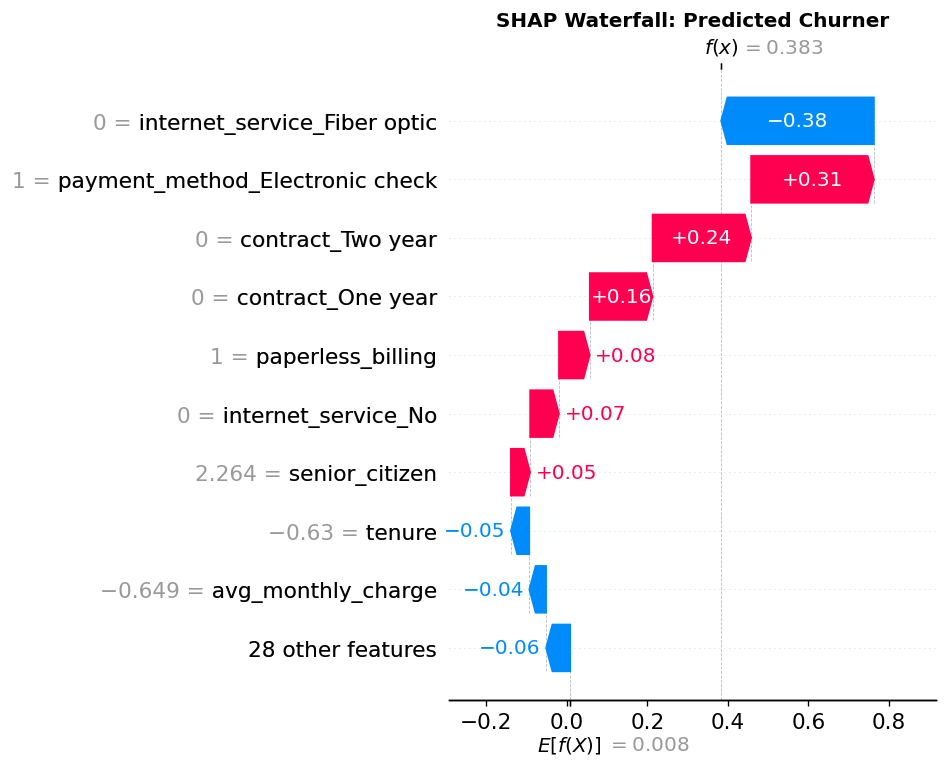

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[churner_idx],
        base_values=base_val,
        data=X_test_proc[churner_idx],
        feature_names=feature_names
    ),
    show=False
)
plt.title('SHAP Waterfall: Predicted Churner', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.2 Waterfall - Predicted Non-Churner

Features here push the prediction *below* the base value (retention).

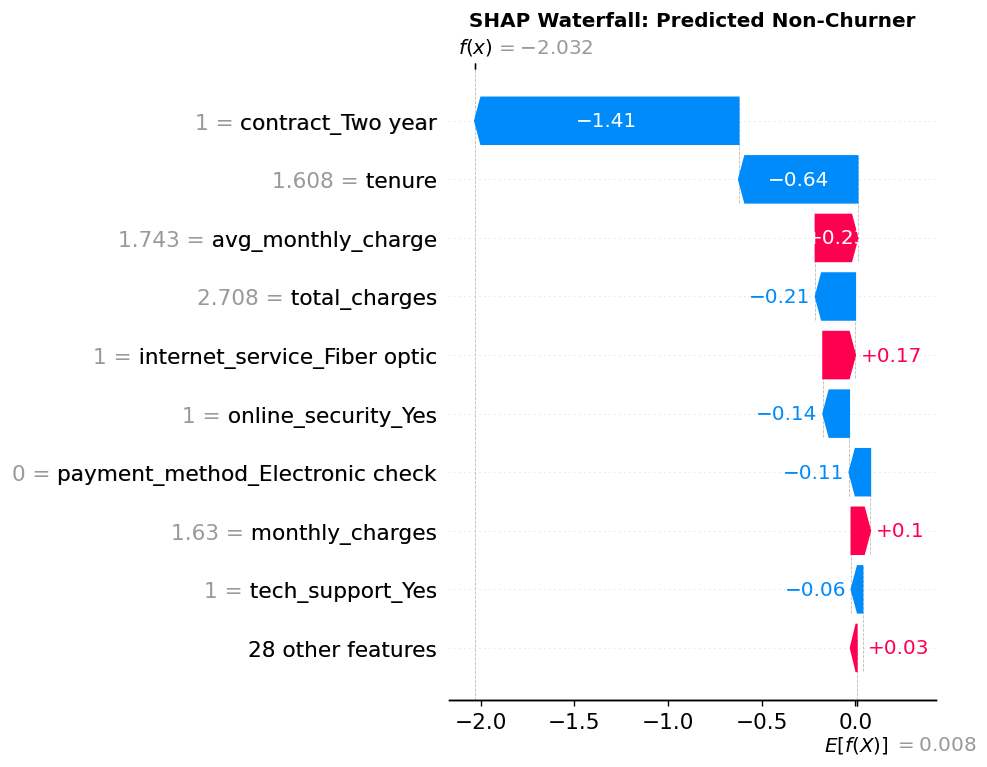

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[non_churner_idx],
        base_values=base_val,
        data=X_test_proc[non_churner_idx],
        feature_names=feature_names
    ),
    show=False
)
plt.title('SHAP Waterfall: Predicted Non-Churner', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.3 Force Plot (Interactive)

Interactive visualisation of feature contributions. Best viewed in Jupyter (requires `shap.initjs()`).

In [20]:
shap.force_plot(
    base_val,
    shap_values[churner_idx],
    X_test_proc[churner_idx],
    feature_names=feature_names,
    matplotlib=False
)

---
## 8. Compare Churners vs. Non-Churners <a id='8'></a>

Overlay mean |SHAP| values for churned and retained customers to find features that *separate* the two groups.

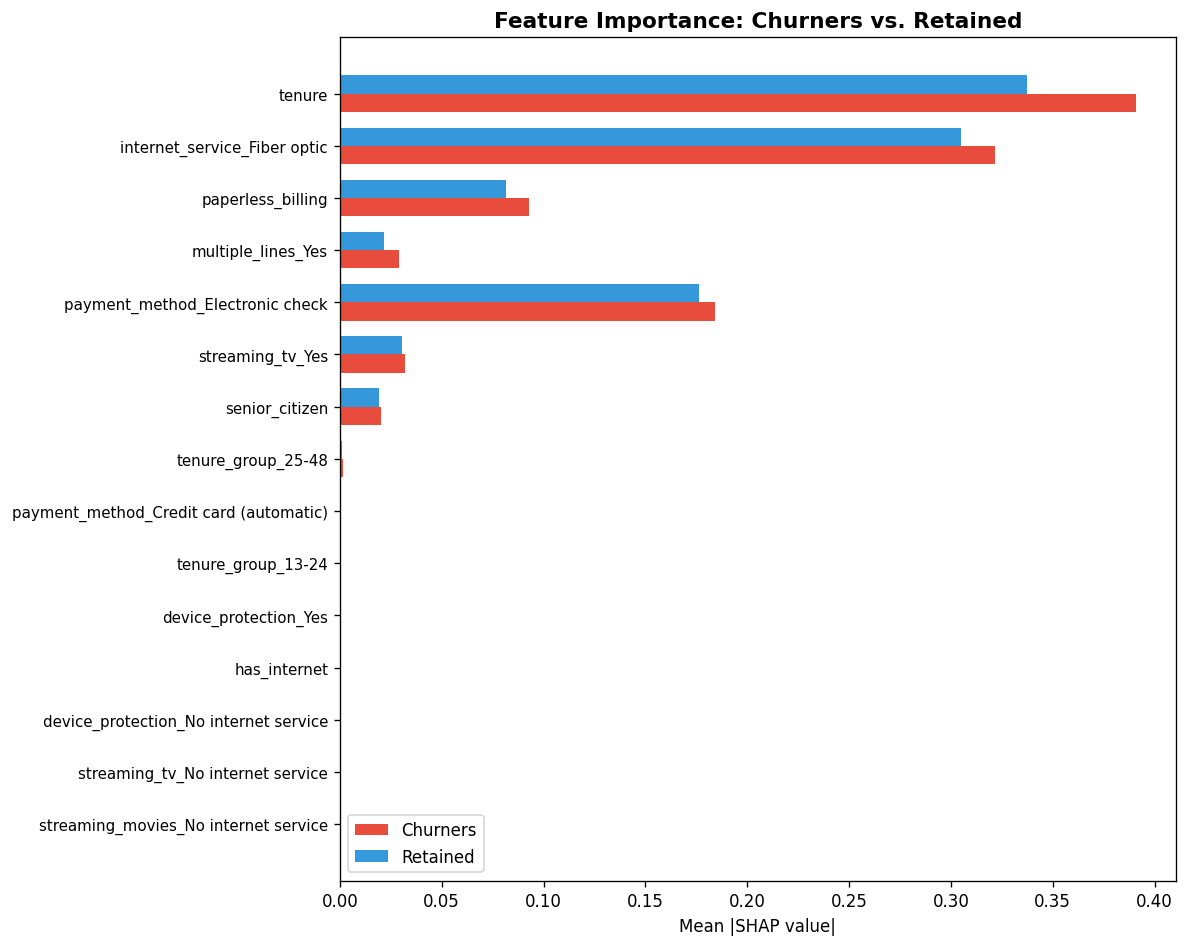

,feature,churners,retained,difference
0,tenure,0.390945,0.337322,0.053623
8,internet_service_Fiber optic,0.321482,0.304750,0.016732
34,paperless_billing,0.092863,0.081794,0.011069
7,multiple_lines_Yes,0.029226,0.021484,0.007741
25,payment_method_Electronic check,0.184049,0.176406,0.007644
19,streaming_tv_Yes,0.032219,0.030351,0.001868
3,senior_citizen,0.020118,0.019103,0.001016
28,tenure_group_25-48,0.001360,0.001204,0.000156
24,payment_method_Credit card (automatic),0.000741,0.000605,0.000136
27,tenure_group_13-24,0.000303,0.000276,0.000027


In [21]:
churn_mask = y_test.values == 1
retain_mask = ~churn_mask

mean_shap_churn = np.mean(np.abs(shap_values[churn_mask]), axis=0)
mean_shap_retain = np.mean(np.abs(shap_values[retain_mask]), axis=0)

comparison = pd.DataFrame({
    'feature': feature_names,
    'churners': mean_shap_churn,
    'retained': mean_shap_retain,
    'difference': mean_shap_churn - mean_shap_retain
}).sort_values('difference', ascending=False)

# Plot top 15 features with biggest difference
top_diff = comparison.head(15)
x = np.arange(len(top_diff))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(x + width/2, top_diff['churners'], width, label='Churners', color='#e74c3c')
ax.barh(x - width/2, top_diff['retained'], width, label='Retained', color='#3498db')

ax.set_yticks(x)
ax.set_yticklabels(top_diff['feature'], fontsize=9)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Feature Importance: Churners vs. Retained', fontsize=13, fontweight='bold')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Table view
comparison.head(10)

---
## 9. Key Takeaways <a id='9'></a>

**What to look for in SHAP plots:**

1. **High |SHAP| features** -> Drive the model most. If business-actionable, prioritise them.
2. **Red on the right** -> High feature values pushing toward churn.
3. **Blue on the left** -> Low feature values pushing toward churn (e.g., short tenure).
4. **Dependence curves** -> Non-linear relationships. Flat = unused; steep = highly influential.
5. **Waterfall plots** -> For individual customers, identify top 3-4 reasons for the flag. Personalise retention offers accordingly.

**Business actions from SHAP insights:**
- If `contract_Two year` strongly prevents churn -> offer longer contracts to at-risk customers.
- If `internet_service_Fiber optic` drives churn -> investigate fibre pricing/quality.
- If `tenure` is the top feature -> invest in early-stage onboarding programmes.